In [1]:
import sys
sys.path.append('..')
from run.run_gspa import calculate_wavelet_dictionary
from run.run_ae_default_config import run_ae
from utils import *
import scprep
import scanpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import phate
import seaborn as sns
import magic
import meld
from collections import defaultdict
import leidenalg
from sklearn.preprocessing import scale

## Load data (manuscript in progress with collaborators) & visualize samples and annotated cell types
### NO_AG: no antigen
### AG: antigen
### AG+CPI: antigen with checkpoint inhibitors

In [5]:
adata = scanpy.read_h5ad('./data/skin_processed_human_name.h5ad')
adata.obs['samples'] = [x[:-2] for x in adata.obs.sample_labels]
adata.var_names = adata.var.symbol

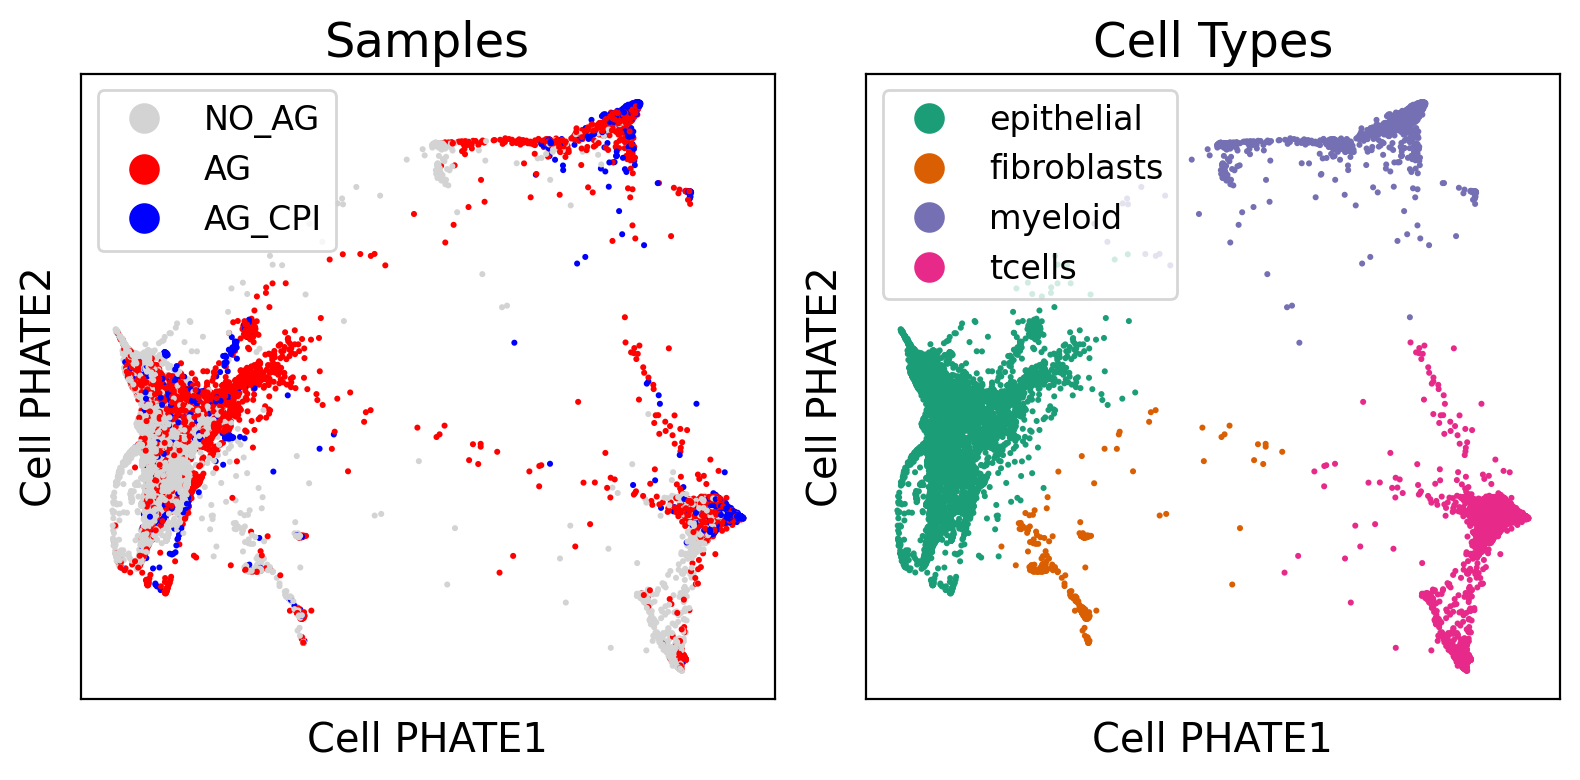

In [6]:
fig, ax = plt.subplots(1,2, figsize=(8,4), dpi=200); ax=ax.flatten()
scprep.plot.scatter2d(adata.obsm['X_PHATE'], c=adata.obs.samples, figsize=(4.3,3),
                     title=f'Samples', label_prefix='Cell PHATE', ticks=None, ax=ax[0],
                     cmap={'NO_AG': 'lightgray', 'AG':'red', 'AG_CPI':'blue'})

scprep.plot.scatter2d(adata.obsm['X_PHATE'], c=adata.obs.cell_types,figsize=(4.3,3),
                     title=f'Cell Types', label_prefix='Cell PHATE', ticks=None, ax=ax[1],
                     cmap=sns.color_palette('Dark2')[:4])

plt.tight_layout()
fig.savefig('./figures/samples_cell_types.png', dpi=200)

## Generate cell-cell similarity graph used for PHATE, MAGIC, and MELD

In [10]:
phate_op = phate.PHATE(random_state=42, knn=40, decay=10, use_pygsp=True)
phate_op.fit(adata.obsm['X_PCA'])

Running PHATE on 21178 observations and 100 variables.
Calculating graph and diffusion operator...
  Calculating KNN search...
  Calculated KNN search in 51.07 seconds.
  Calculating affinities...
  Calculated affinities in 61.23 seconds.
Calculated graph and diffusion operator in 118.67 seconds.
Calculating landmark operator...
  Calculating SVD...
  Calculated SVD in 38.95 seconds.
  Calculating KMeans...
  Calculated KMeans in 6.54 seconds.
Calculated landmark operator in 49.44 seconds.


PHATE(decay=10, knn=40, random_state=42)

In [11]:
G = phate_op.graph
del(phate_op) ## save memory by deleting large objects

## Run MELD to compute each condition likelihood

In [12]:
meld_op = meld.MELD()
meld_op.graph = G

all_sample_densities = meld_op.transform(adata.obs['samples'])
all_sample_likelihoods = meld.normalize_densities(all_sample_densities)

del(meld_op)

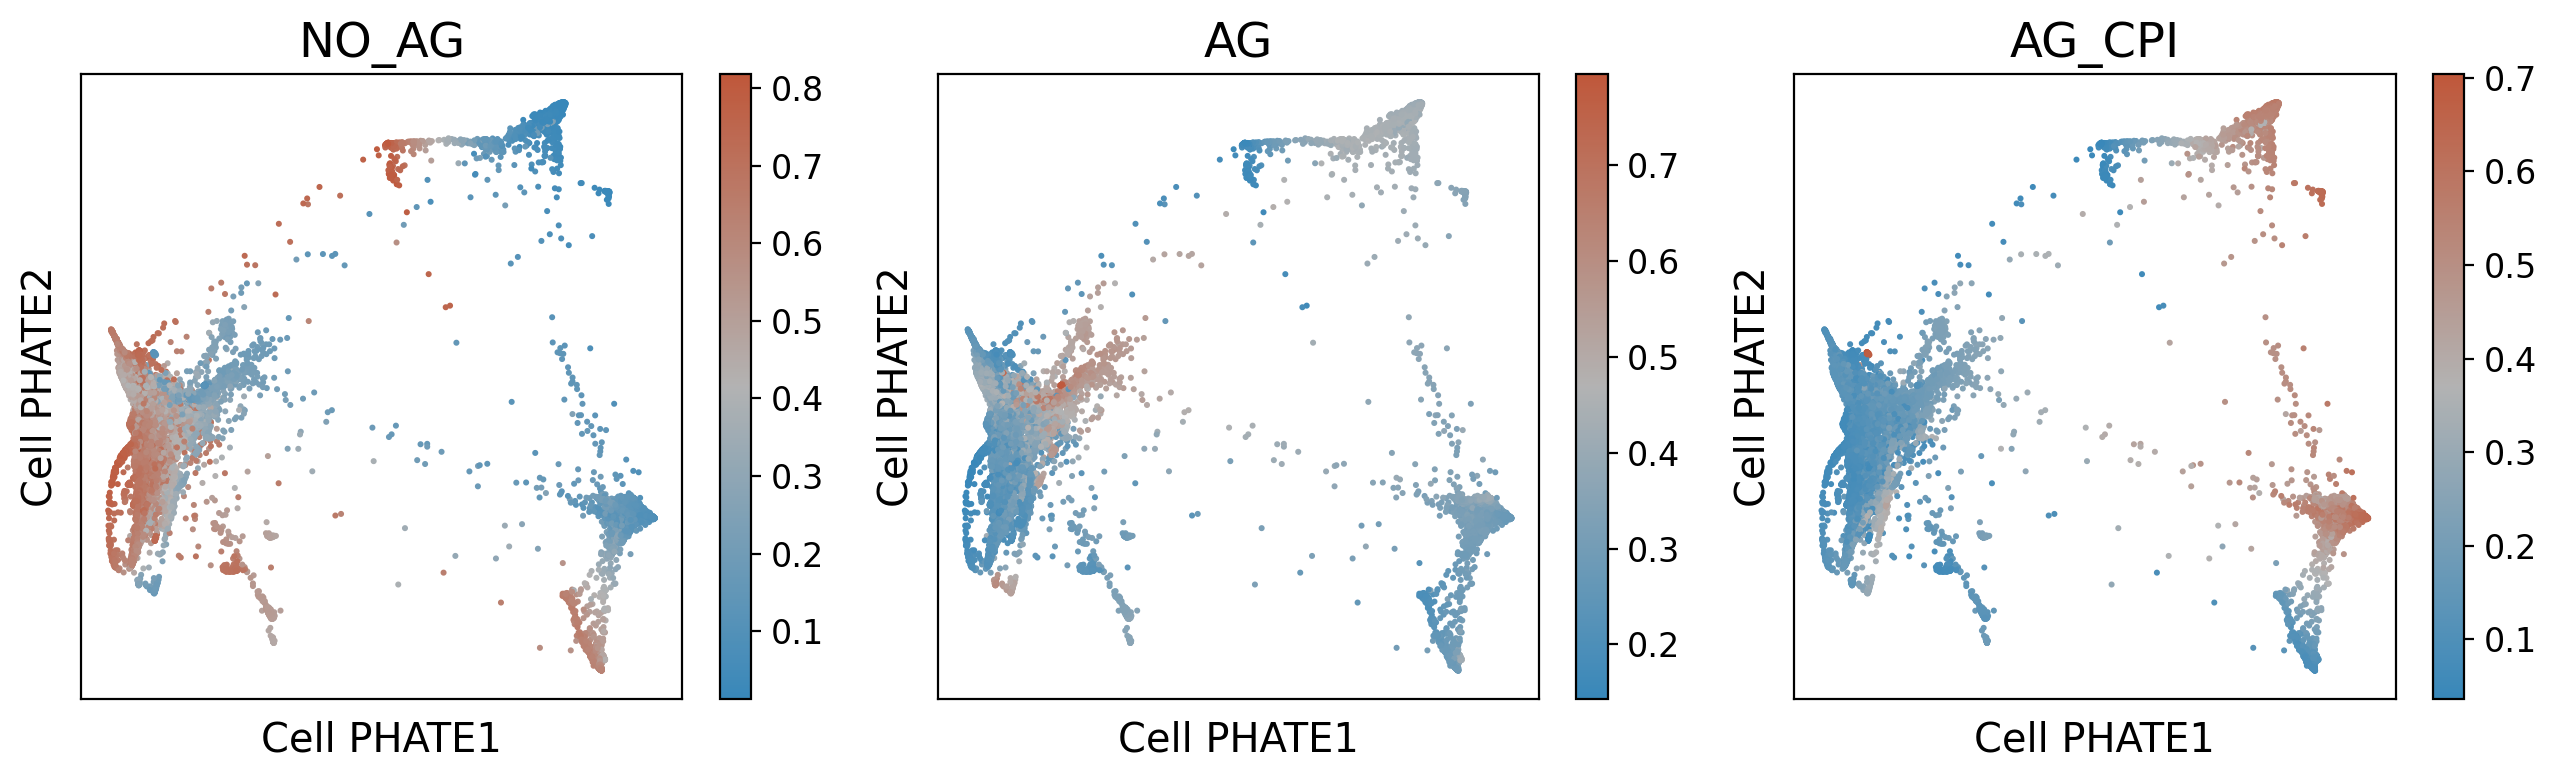

In [13]:
fig, ax = plt.subplots(1,3, figsize=(13,4), dpi=200); ax=ax.flatten()

for i,condition in enumerate(['NO_AG', 'AG', 'AG_CPI']):
    scprep.plot.scatter2d(adata.obsm['X_PHATE'], c=all_sample_likelihoods[condition],
                     title=condition, label_prefix='Cell PHATE', ticks=None, ax=ax[i],
                      cmap=meld.get_meld_cmap())
    
plt.tight_layout()
fig.savefig('./figures/conditions.png', dpi=200)

## Get highly variable genes

In [19]:
hvgs = np.array(adata[:, adata.var.hvg].var.symbol)

## Extract ligand-receptor pairs that are highly and variably expressed from CellChat

In [24]:
signaling_pathways = pd.read_csv('./data/cellchat.csv')[['interaction.pathway_name', 'interaction.interaction_name_2', 'interaction.annotation']]
ligand = [x.split(' - ')[0].strip() for x in signaling_pathways['interaction.interaction_name_2']]
receptors = [x.split(' - ')[1][1:-1].strip().split('+') if '+' in x else x.split(' - ')[1].strip().split('+') for x in signaling_pathways['interaction.interaction_name_2']]

signaling_pathways['ligand'] = ligand
signaling_pathways['receptors'] = receptors

r = []
for row in signaling_pathways.iterrows():
    for receptor in row[1]['receptors']:
        r.append([row[1]['interaction.pathway_name'], row[1]['ligand'], receptor, row[1]['interaction.annotation']])
        
signaling_pathways = pd.DataFrame(r, columns=['pathway', 'ligand', 'receptor', 'interaction']).drop_duplicates()
signaling_pathways_hvgs = signaling_pathways[(signaling_pathways['ligand'].isin(hvgs)) & (signaling_pathways['receptor'].isin(hvgs))]

In [25]:
num_pairs = signaling_pathways_hvgs.shape[0]
signaling_pathways_hvgs.index = range(num_pairs) ## unique pairs where ligand and receptor are both HVGs

In [17]:
data = adata.to_df().loc[:, ~adata.to_df().columns.duplicated()]

## Learn ligand-receptor embedding

In [26]:
dictionary, wavelet_sizes = calculate_wavelet_dictionary(G)

Maximum scale: 9


100%|██████████| 7/7 [1:52:21<00:00, 963.02s/it] 


In [27]:
ligands = data[signaling_pathways_hvgs['ligand']].T
ligands = ligands / np.linalg.norm(ligands, axis=1).reshape(-1,1)

In [28]:
receptors = data[signaling_pathways_hvgs['receptor']].T
receptors = receptors / np.linalg.norm(receptors, axis=1).reshape(-1,1)

In [31]:
ligands_reduced = svd(project(ligands, dictionary))
receptors_reduced = svd(project(receptors, dictionary))

In [221]:
ligand_ae = run_ae(ligands_reduced)
receptor_ae = run_ae(receptors_reduced)

Epoch 1/100
11/11 [==============================] - 0s 13ms/step - loss: 0.0133 - val_loss: 0.0104
Epoch 2/100
11/11 [==============================] - 0s 6ms/step - loss: 0.0100 - val_loss: 0.0094
Epoch 3/100
11/11 [==============================] - 0s 7ms/step - loss: 0.0061 - val_loss: 0.0078
Epoch 4/100
11/11 [==============================] - 0s 6ms/step - loss: 0.0040 - val_loss: 0.0064
Epoch 5/100
11/11 [==============================] - 0s 6ms/step - loss: 0.0030 - val_loss: 0.0059
Epoch 6/100
11/11 [==============================] - 0s 7ms/step - loss: 0.0024 - val_loss: 0.0052
Epoch 7/100
11/11 [==============================] - 0s 7ms/step - loss: 0.0019 - val_loss: 0.0047
Epoch 8/100
11/11 [==============================] - 0s 6ms/step - loss: 0.0016 - val_loss: 0.0042
Epoch 9/100
11/11 [==============================] - 0s 6ms/step - loss: 0.0013 - val_loss: 0.0037
Epoch 10/100
11/11 [==============================] - 0s 6ms/step - loss: 0.0011 - val_loss: 0.0033
Epoch 11

In [222]:
np.save('./results/ligand_embedding.npy', ligands_reduced)
np.save('./results/receptor_embedding.npy', receptors_reduced)